# Bessel Bridge — A Complete Guide

## Cell 1: Introduction

The **Bessel Bridge** is a Bessel process conditioned to hit a specific endpoint at a fixed time. It is the radial part of a $d$-dimensional Brownian motion that starts at one point and is forced to end at another.

### Definition

For **integer dimension** $\delta$, the Bessel bridge from $r_0$ to $r_T$ over $[0,T]$ is:

$$R(t) = \big\| \mathbf{B}(t) \big\|_2$$

where $\mathbf{B}(t) = \big(B_1(t), \dots, B_\delta(t)\big)$ and each $B_i$ is an **independent Brownian bridge** with appropriate endpoints.

### Special Cases

| Dimension | Name | Interpretation |
|-----------|------|----------------|
| $\delta = 1$ | Reflected Brownian bridge | $R(t) = \big| B(t) \big|$ |
| $\delta = 2$ | 2D radial bridge | Norm of planar Brownian bridge |
| $\delta = 3$ | **3D Bessel bridge** | Used in bond pricing, volatility modeling |
| $\delta = 4$ | 4D radial bridge | Appears in random matrix theory |

### Key Properties (Bridge from 0 to 0)

For a Bessel bridge of dimension $\delta$ from 0 to 0:

- **Representation**: $R(t) = \sigma \cdot \sqrt{Q}$ where $Q \sim \chi^2(\delta)$ and $\sigma^2 = \frac{t(T-t)}{T}$
- **Mean**: $\mathbb{E}[R(t)] = \sigma \cdot \sqrt{2} \cdot \frac{\Gamma\big(\frac{\delta+1}{2}\big)}{\Gamma\big(\frac{\delta}{2}\big)}$
- **Variance of $R(t)^2$**: $\text{Var}[R(t)^2] = 2\delta \cdot \sigma^4$
- **Density**:
$$f(r) = \frac{r^{\delta-1} \exp\!\big(-\frac{r^2}{2\sigma^2}\big)}{2^{\frac{\delta}{2}-1} \cdot \Gamma\!\big(\frac{\delta}{2}\big) \cdot \sigma^\delta}$$

### Simulation Method

For **integer** $\delta$:
1. Generate $\delta$ independent 1D Brownian bridges
2. Take the Euclidean norm at each time step
3. 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
from scipy.special import gamma as gamma_func
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


def simulate_brownian_bridge(T, n_steps, n_paths, x=0.0, y=0.0):
    """
    Simulate 1D Brownian bridge from x at t=0 to y at t=T.
    B(t) = x + (y-x)*t/T + W(t) - t/T*W(T)
    """
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    dW = np.random.normal(0, np.sqrt(dt), (n_paths, n_steps))
    W = np.zeros((n_paths, n_steps + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    B = np.zeros((n_paths, n_steps + 1))
    for k in range(n_paths):
        B[k] = x + (y - x) * t / T + W[k] - t / T * W[k, -1]
    return t, B


def simulate_bessel_bridge(delta, T, n_steps, n_paths, r0=0.0, rT=0.0):
    """
    Simulate Bessel bridge of integer dimension delta from r0 to rT over [0,T].
    For integer delta: norm of delta independent Brownian bridge components.
    """
    t = np.linspace(0, T, n_steps + 1)
    delta_int = int(delta)
    
    if delta_int == 1:
        _, B = simulate_brownian_bridge(T, n_steps, n_paths, x=r0, y=rT)
        return t, np.abs(B)
    
    components = np.zeros((n_paths, n_steps + 1, delta_int))
    
    if r0 == 0.0 and rT == 0.0:
        # All components start and end at 0
        for d in range(delta_int):
            _, B = simulate_brownian_bridge(T, n_steps, n_paths, x=0.0, y=0.0)
            components[:, :, d] = B
    else:
        # Random directions on spheres for start and end points
        start_dirs = np.random.normal(0, 1, (n_paths, delta_int))
        norms = np.linalg.norm(start_dirs, axis=1, keepdims=True)
        start_dirs = start_dirs / norms
        
        end_dirs = np.random.normal(0, 1, (n_paths, delta_int))
        norms = np.linalg.norm(end_dirs, axis=1, keepdims=True)
        end_dirs = end_dirs / norms
        
        for d in range(delta_int):
            x_d = r0 * start_dirs[:, d]
            y_d = rT * end_dirs[:, d]
            _, B = simulate_brownian_bridge(T, n_steps, n_paths, x=0.0, y=0.0)
            for k in range(n_paths):
                B[k] += x_d[k] + (y_d[k] - x_d[k]) * t / T
            components[:, :, d] = B
    
    R = np.sqrt(np.sum(components**2, axis=2))
    return t, R


def bessel_bridge_density_0_to_0(r, delta, t, T):
    """
    Exact density of Bessel bridge (dimension delta) from 0 to 0 at time t.
    
    R_t^2 / sigma^2 ~ chi^2(delta), where sigma^2 = t*(T-t)/T.
    
    f(r) = r^(delta-1) * exp(-r^2/(2*sigma^2)) 
           / (2^(delta/2 - 1) * Gamma(delta/2) * sigma^delta)
    """
    sigma2 = t * (T - t) / T
    sigma = np.sqrt(sigma2)
    nu = delta / 2.0 - 1.0
    density = (r**(delta - 1) * np.exp(-r**2 / (2 * sigma2)) 
               / (2**nu * gamma_func(delta / 2.0) * sigma**delta))
    return density


def simulate_standard_bessel(delta, T, n_steps, n_paths, r0=0.0):
    """Simulate standard Bessel process (NOT bridged) using Euler-Maruyama."""
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    R = np.zeros((n_paths, n_steps + 1))
    R[:, 0] = r0
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        R_pos = np.maximum(R[:, i], 0.001)  # avoid division by zero
        drift = (delta - 1) / (2 * R_pos) * dt
        R[:, i + 1] = R[:, i] + drift + dW
        R[:, i + 1] = np.abs(R[:, i + 1])
    return t, R


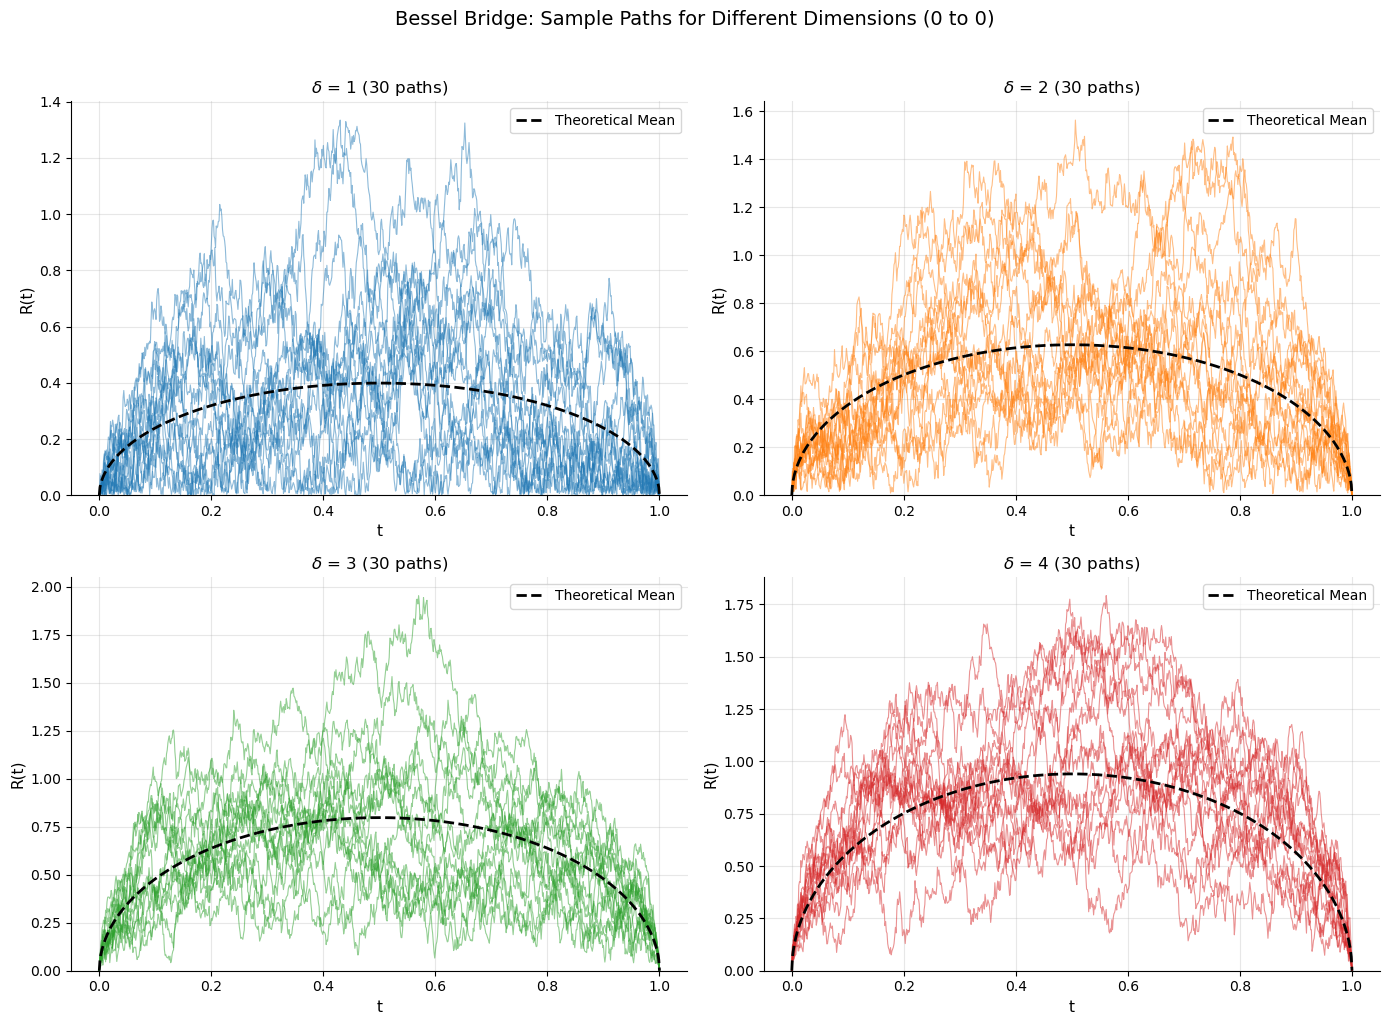

In [16]:
T = 1.0
n_steps = 800
n_paths = 30
deltas = [1, 2, 3, 4]
colors_dim = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (delta, color) in enumerate(zip(deltas, colors_dim)):
    ax = axes[idx]
    t, R = simulate_bessel_bridge(delta, T, n_steps, n_paths, r0=0.0, rT=0.0)
    
    for k in range(min(15, n_paths)):
        ax.plot(t, R[k], alpha=0.5, lw=0.8, color=color)
    
    # Theoretical mean
    sigma_t = np.sqrt(t * (T - t) / T)
    if delta == 1:
        mean_theo = sigma_t * np.sqrt(2 / np.pi)
    elif delta == 2:
        mean_theo = sigma_t * np.sqrt(np.pi / 2)
    elif delta == 3:
        mean_theo = sigma_t * np.sqrt(2) * gamma_func(2) / gamma_func(1.5)
    elif delta == 4:
        mean_theo = sigma_t * np.sqrt(2) * gamma_func(2.5) / gamma_func(2)
    
    ax.plot(t, mean_theo, 'k--', lw=2, label='Theoretical Mean')
    ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
    ax.set_xlabel('t', fontsize=11)
    ax.set_ylabel('R(t)', fontsize=11)
    ax.set_title(r'$\delta$ = %d (%d paths)' % (delta, n_paths), fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bessel Bridge: Sample Paths for Different Dimensions (0 to 0)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 2: What the Paths Show

- All paths **start at 0** and **end at 0** — this is the bridge conditioning
- The **mean curve** (black dashed) peaks at $t = T/2$ and has a symmetric arch shape
- Higher $\delta$ means **larger typical values** and **wider spread**
- For $\delta = 1$, paths frequently touch zero (reflected BM behavior)
- For $\delta \geq 2$, paths tend to stay away from zero (higher-dimensional radial process)

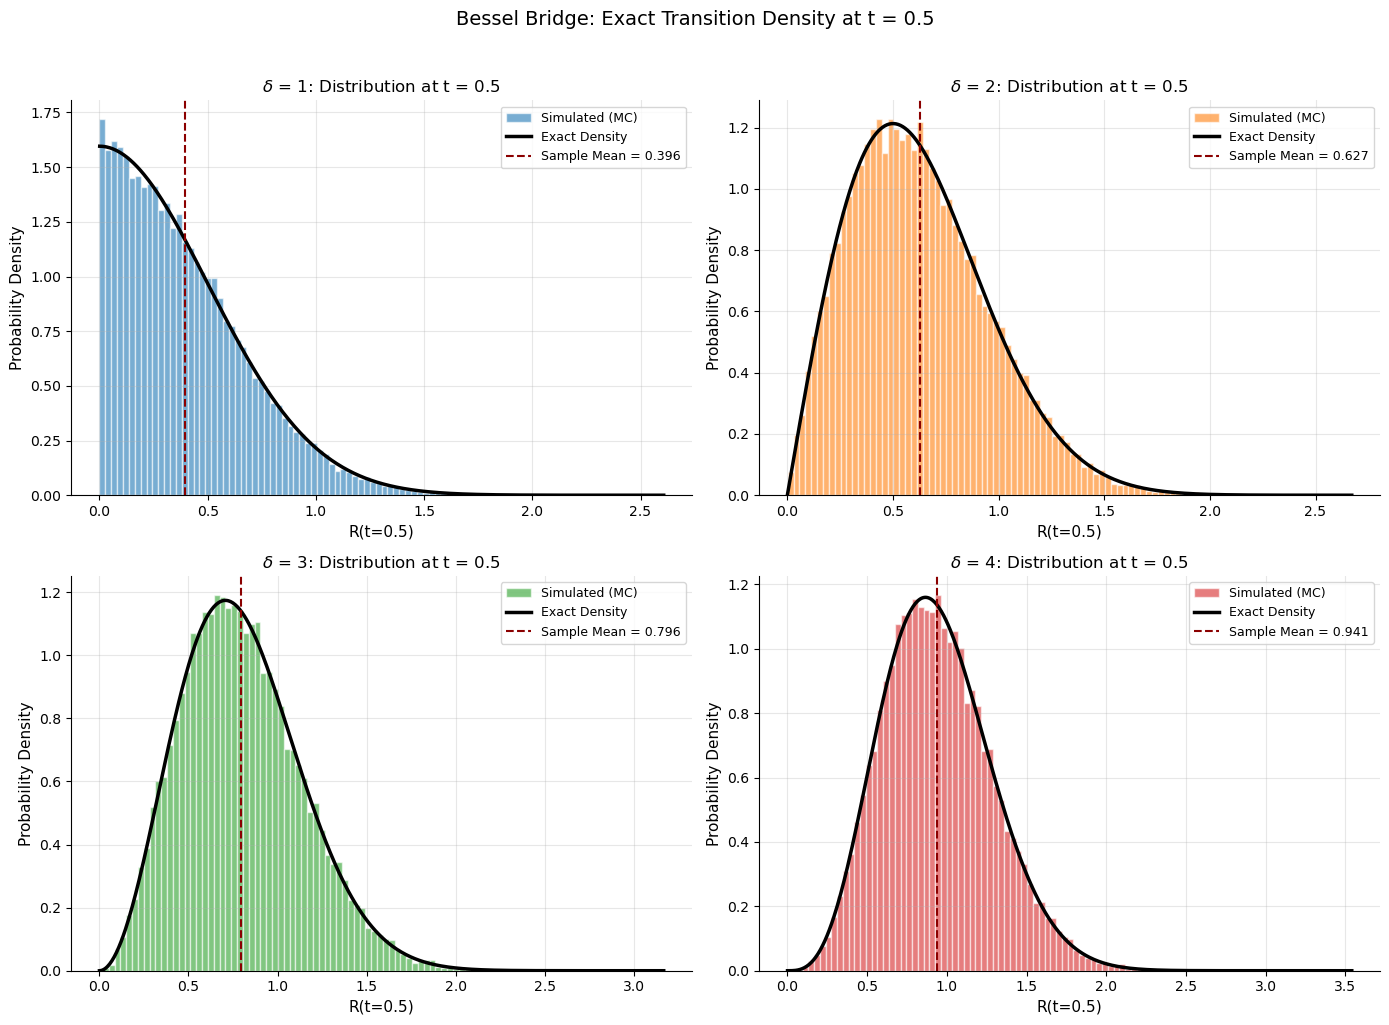

In [17]:
T = 1.0
n_steps = 800
n_mc = 30000
t_eval = 0.5
idx = int(t_eval / T * n_steps)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx_dim, (delta, color) in enumerate(zip(deltas, colors_dim)):
    ax = axes[idx_dim]
    t, R = simulate_bessel_bridge(delta, T, n_steps, n_mc, r0=0.0, rT=0.0)
    r_vals = R[:, idx]
    r_vals = r_vals[r_vals >= 0]
    
    ax.hist(r_vals, bins=80, density=True, alpha=0.6, color=color,
            edgecolor='white', label='Simulated (MC)')
    
    r_max = max(r_vals) * 1.2
    r_grid = np.linspace(0.001, r_max, 500)
    theo_density = bessel_bridge_density_0_to_0(r_grid, delta, t_eval, T)
    ax.plot(r_grid, theo_density, 'k-', lw=2.5, label='Exact Density')
    
    mean_mc = np.mean(r_vals)
    ax.axvline(x=mean_mc, color='darkred', linestyle='--', lw=1.5,
               label='Sample Mean = %.3f' % mean_mc)
    
    ax.set_xlabel('R(t=%.1f)' % t_eval, fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.set_title(r'$\delta$ = %d: Distribution at t = %.1f' % (delta, t_eval), fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bessel Bridge: Exact Transition Density at t = 0.5', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 3: Exact Density Derivation

For the **0-to-0 Bessel bridge**, the key insight is:

$$R(t)^2 = \sigma^2 \cdot Q \quad \text{where} \quad Q \sim \chi^2(\delta), \quad \sigma^2 = \frac{t(T-t)}{T}$$

This is because each coordinate of the underlying Brownian bridge is $\mathcal{N}(0, \sigma^2)$, so the squared norm is $\sigma^2$ times a chi-square with $\delta$ degrees of freedom.

| Dimension | Distribution Name | Shape |
|-----------|------------------|-------|
| $\delta = 1$ | Half-normal | Decreasing from 0 |
| $\delta = 2$ | Rayleigh | Single peak near 0.4 |
| $\delta = 3$ | Maxwell-Boltzmann | Bell-shaped, starts at 0 |
| $\delta = 4$ | Chi-like | More symmetric, Gaussian-like |

The near-perfect overlap between Monte Carlo histograms and the black exact density curves confirms both the theory and the simulation.


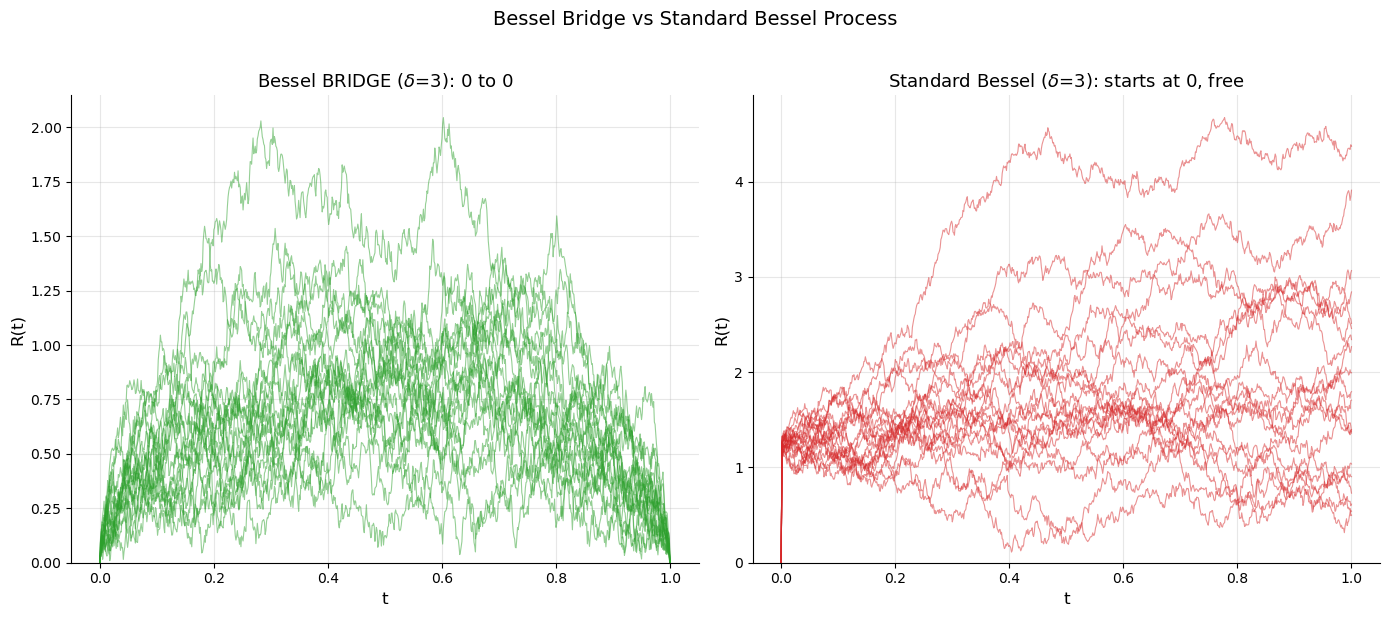

In [18]:
T = 1.0
n_steps = 800
n_paths = 20
delta = 3

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bessel Bridge
ax = axes[0]
t_bridge, R_bridge = simulate_bessel_bridge(delta, T, n_steps, n_paths, r0=0.0, rT=0.0)
for k in range(n_paths):
    ax.plot(t_bridge, R_bridge[k], alpha=0.5, lw=0.8, color='#2ca02c')
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('R(t)', fontsize=12)
ax.set_title(r'Bessel BRIDGE ($\delta$=%d): 0 to 0' % delta, fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Standard Bessel
ax = axes[1]
t_std, R_std = simulate_standard_bessel(delta, T, n_steps, n_paths, r0=0.0)
for k in range(n_paths):
    ax.plot(t_std, R_std[k], alpha=0.5, lw=0.8, color='#d62728')
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('R(t)', fontsize=12)
ax.set_title(r'Standard Bessel ($\delta$=%d): starts at 0, free' % delta, fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Bessel Bridge vs Standard Bessel Process', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 4: Bridge vs Free Process

| Feature | Bessel Bridge | Standard Bessel |
|---------|--------------|-----------------|
| **Endpoints** | Pinned at both $t=0$ and $t=T$ | Free, only initial condition |
| **Drift** | Implicit via conditioning | Explicit: $\frac{\delta-1}{2R}dt$ |
| **Behavior** | Returns to origin | Drifts away, never returns |
| **Variance** | Peaks at $t=T/2$, then shrinks | Grows linearly with time |
| **Use case** | Bond pricing, path conditioning | Interest rates, default modeling |

The bridge is a **conditioned** version of the free process. If you took all standard Bessel paths that happen to return to 0 at time $T$ and looked at their distribution, you would recover the Bessel bridge.


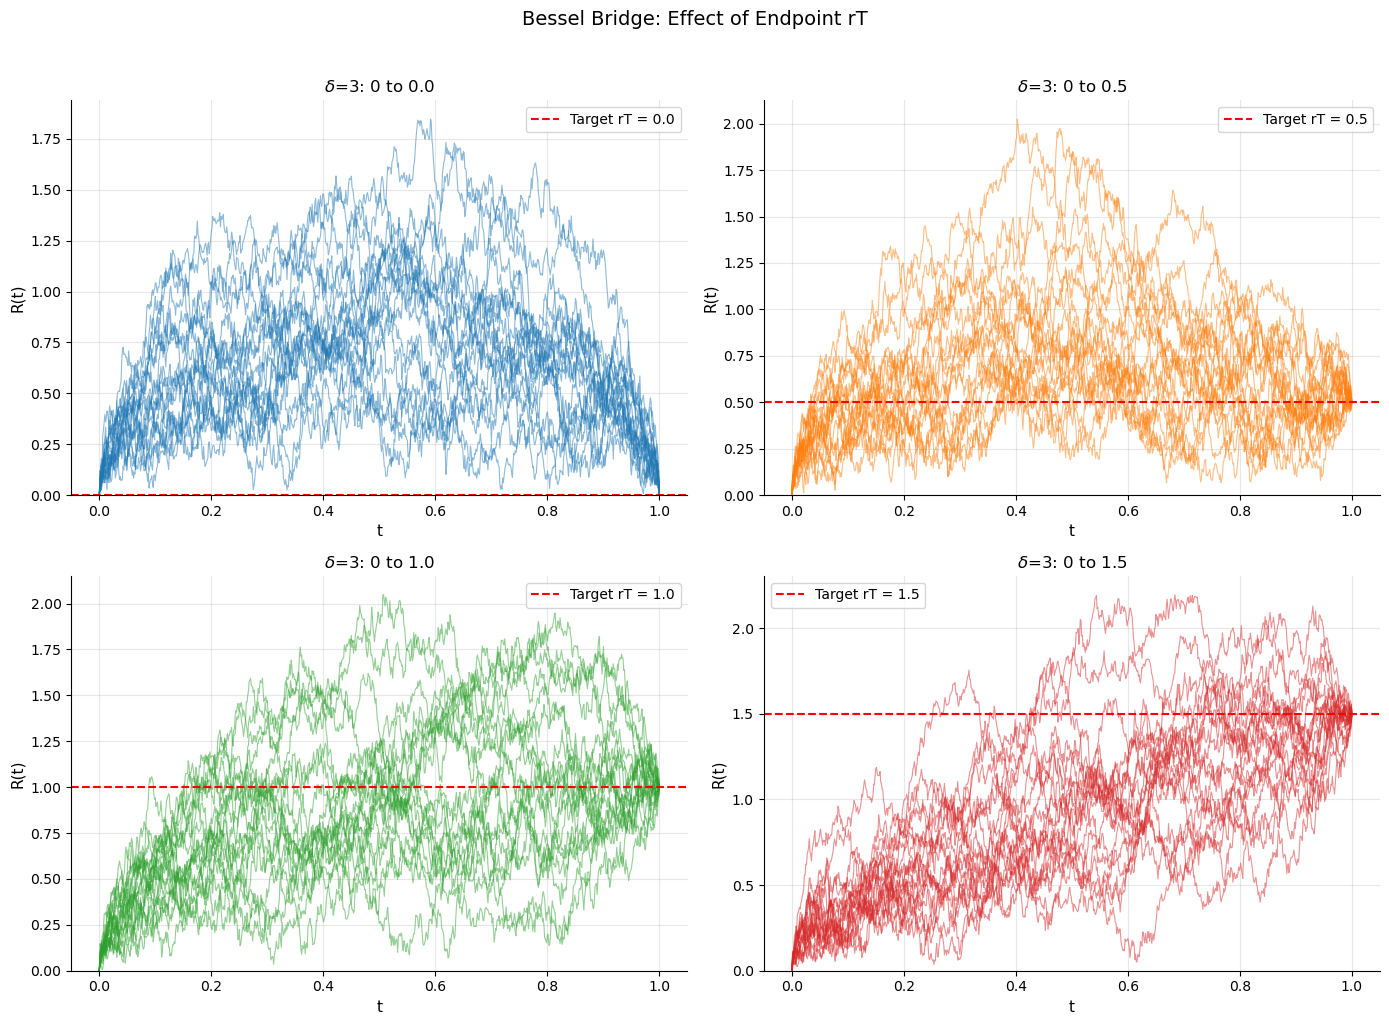

In [19]:
T = 1.0
n_steps = 800
n_paths = 20
delta = 3

rT_values = [0.0, 0.5, 1.0, 1.5]
colors_r = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (rT, color) in enumerate(zip(rT_values, colors_r)):
    ax = axes[idx]
    t, R = simulate_bessel_bridge(delta, T, n_steps, n_paths, r0=0.0, rT=rT)
    for k in range(n_paths):
        ax.plot(t, R[k], alpha=0.5, lw=0.8, color=color)
    ax.axhline(y=rT, color='red', linestyle='--', lw=1.5, label='Target rT = %.1f' % rT)
    ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
    ax.set_xlabel('t', fontsize=11)
    ax.set_ylabel('R(t)', fontsize=11)
    ax.set_title(r'$\delta$=%d: 0 to %.1f' % (delta, rT), fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bessel Bridge: Effect of Endpoint rT', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 5: Endpoint Interpretation

As the target endpoint $r_T$ increases:
- The entire **cloud of paths shifts upward**
- The **mean trajectory** tilts from a symmetric arch toward a rising curve
- The **variance structure** changes — paths have less freedom near $t=T$ because they must converge to $r_T$

For $r_T = 0$, the mean is symmetric. For $r_T > 0$, the mean at time $t$ is approximately the linear interpolation between 0 and $r_T$, plus a correction from the Bessel drift.


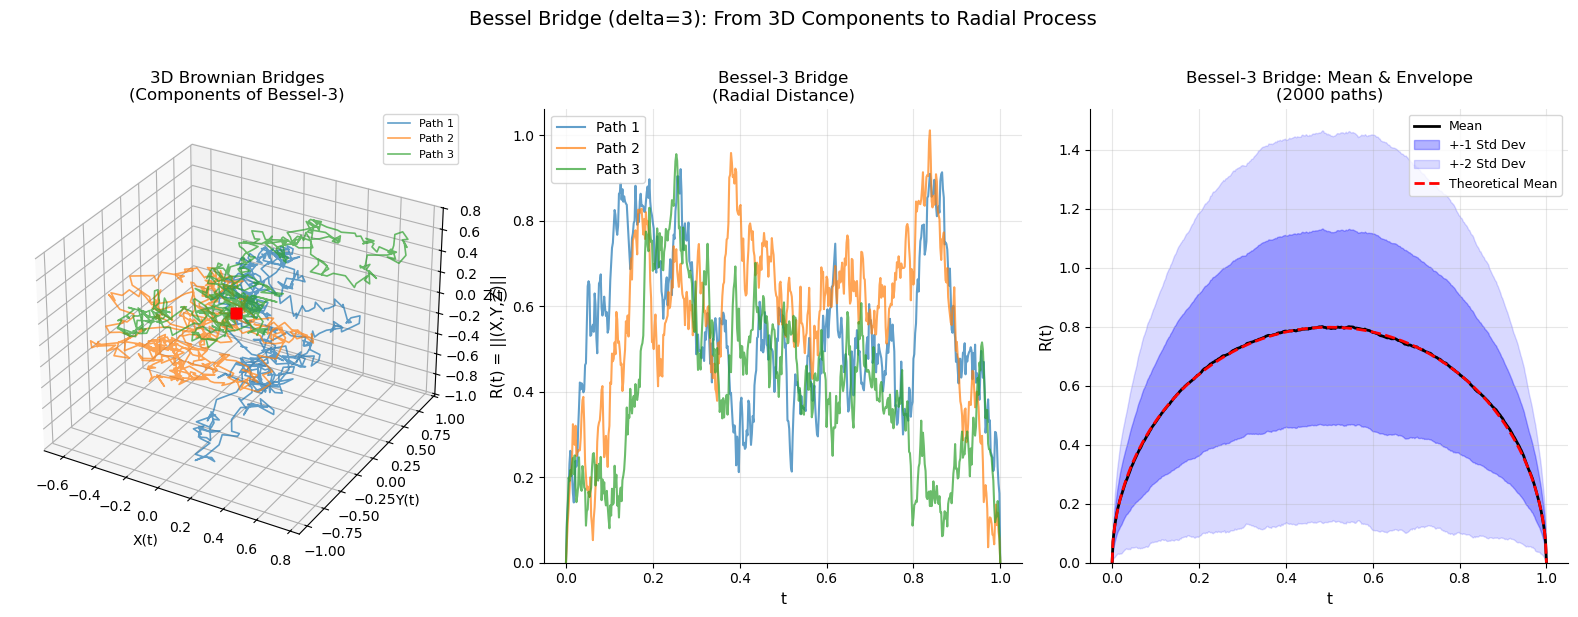

In [20]:
T = 1.0
n_steps = 500
n_paths = 3

fig = plt.figure(figsize=(16, 6))

# Left: 3D Brownian bridge components
ax1 = fig.add_subplot(131, projection='3d')
for k in range(n_paths):
    _, Bx = simulate_brownian_bridge(T, n_steps, 1, x=0.0, y=0.0)
    _, By = simulate_brownian_bridge(T, n_steps, 1, x=0.0, y=0.0)
    _, Bz = simulate_brownian_bridge(T, n_steps, 1, x=0.0, y=0.0)
    colors_3d = ['#1f77b4', '#ff7f0e', '#2ca02c']
    ax1.plot(Bx[0], By[0], Bz[0], alpha=0.7, lw=1.2, color=colors_3d[k],
             label='Path %d' % (k+1))
    ax1.scatter([0], [0], [0], color='black', s=50, marker='o')
    ax1.scatter([0], [0], [0], color='red', s=50, marker='s')
ax1.set_xlabel('X(t)', fontsize=10)
ax1.set_ylabel('Y(t)', fontsize=10)
ax1.set_zlabel('Z(t)', fontsize=10)
ax1.set_title('3D Brownian Bridges\n(Components of Bessel-3)', fontsize=12)
ax1.legend(fontsize=8)

# Middle: Radial distance
ax2 = fig.add_subplot(132)
t, R = simulate_bessel_bridge(3, T, n_steps, n_paths, r0=0.0, rT=0.0)
for k in range(n_paths):
    ax2.plot(t, R[k], alpha=0.7, lw=1.5, color=colors_3d[k],
             label='Path %d' % (k+1))
ax2.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax2.set_xlabel('t', fontsize=11)
ax2.set_ylabel('R(t) = ||(X,Y,Z)||', fontsize=11)
ax2.set_title('Bessel-3 Bridge\n(Radial Distance)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Right: Mean and envelope
ax3 = fig.add_subplot(133)
t, R_many = simulate_bessel_bridge(3, T, n_steps, 2000, r0=0.0, rT=0.0)
mean_R = np.mean(R_many, axis=0)
std_R = np.std(R_many, axis=0)

ax3.plot(t, mean_R, 'k-', lw=2, label='Mean')
ax3.fill_between(t, mean_R - std_R, mean_R + std_R, alpha=0.3, color='blue',
                 label='+-1 Std Dev')
ax3.fill_between(t, mean_R - 2*std_R, mean_R + 2*std_R, alpha=0.15, color='blue',
                 label='+-2 Std Dev')

sigma_t = np.sqrt(t * (T - t) / T)
theo_mean = sigma_t * np.sqrt(2) * gamma_func(2) / gamma_func(1.5)
ax3.plot(t, theo_mean, 'r--', lw=2, label='Theoretical Mean')

ax3.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax3.set_xlabel('t', fontsize=11)
ax3.set_ylabel('R(t)', fontsize=11)
ax3.set_title('Bessel-3 Bridge: Mean & Envelope\n(2000 paths)', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(bottom=0)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.suptitle('Bessel Bridge (delta=3): From 3D Components to Radial Process', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 6: The 3D Picture

This plot reveals the **construction** of the Bessel-3 bridge:

1. **Left panel**: Three independent 3D Brownian bridges, each starting and ending at the origin. They wander through space but are pinned at both ends.

2. **Middle panel**: The **radial distance** $R(t) = \sqrt{X^2 + Y^2 + Z^2}$ from the same three paths. This is the Bessel-3 bridge.

3. **Right panel**: The **mean** (black) and **standard deviation bands** (blue shaded) across 2,000 paths. The red dashed theoretical mean overlays almost perfectly.

The Bessel bridge is essentially "how far am I from the origin" when my 3D Brownian motion is forced to return home at time $T$.


## Cell 7: Summary Cheat Sheet

```text
BESSEL BRIDGE (integer dimension delta, from 0 to 0)

Construction:   R(t) = ||B(t)|| where B(t) is delta-dim Brownian bridge
                Each component: B_i(t) ~ N(0, t*(T-t)/T)

Representation: R(t)^2 = sigma^2 * Q,  Q ~ chi^2(delta)
                sigma^2 = t*(T-t)/T

Density:        f(r) = r^(delta-1) * exp(-r^2/(2*sigma^2))
                      / (2^(delta/2 - 1) * Gamma(delta/2) * sigma^delta)

Mean:           E[R(t)] = sigma * sqrt(2) * Gamma((delta+1)/2) / Gamma(delta/2)

Var[R(t)^2]:    2*delta * sigma^4

Simulation:     1. Generate delta independent Brownian bridges
                2. Take Euclidean norm at each time step

Special cases:
  delta=1:  |Brownian bridge|  (half-normal)
  delta=2:  Planar radial      (Rayleigh)
  delta=3:  3D radial          (Maxwell-Boltzmann)
  delta=4:  4D radial          (Chi distribution)
